In [6]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

## Forma dei dati (Bode modulo)

Le quantità che uso per il fit sono:

- Variabile indipendente:
$$
x = \log_{10} (f)
$$

- Errore su x (trascurato):
$$
\sigma_x = 0
$$

- Variabile dipendente (in dB):
$$
y = 20 \log_{10}\!\left(\frac{V_{out}}{V_{in}}\right)
$$

- Errore su y:
$$
\sigma_y = 20 \frac{\sigma_A}{A \ln 10}
\quad \text{con} \quad
A = \frac{V_{out}}{V_{in}}
$$

---

## Modello fittato

Per un filtro RC passa-basso:

$$
y(f) = -10 \log_{10}\!\left(1 + \left(\frac{f}{f_c}\right)^2 \right)
$$

dove:
- $( f )$ = frequenza
- $( f_c )$ = frequenza di taglio (parametro del fit)

---

## Parametro fisico ricavato

Dalla frequenza di taglio:

$$
RC = \frac{1}{2\pi f_c}
$$

In [7]:
def modello(par, x):
    return -10 * np.log10(1 + ( 10**(x + par[1]) / par[0])**2) + par[2]

param_labels = ["f_c", "x_off", "y_off"]

beta0 = [5.20005 * 10**3, 0, 0]

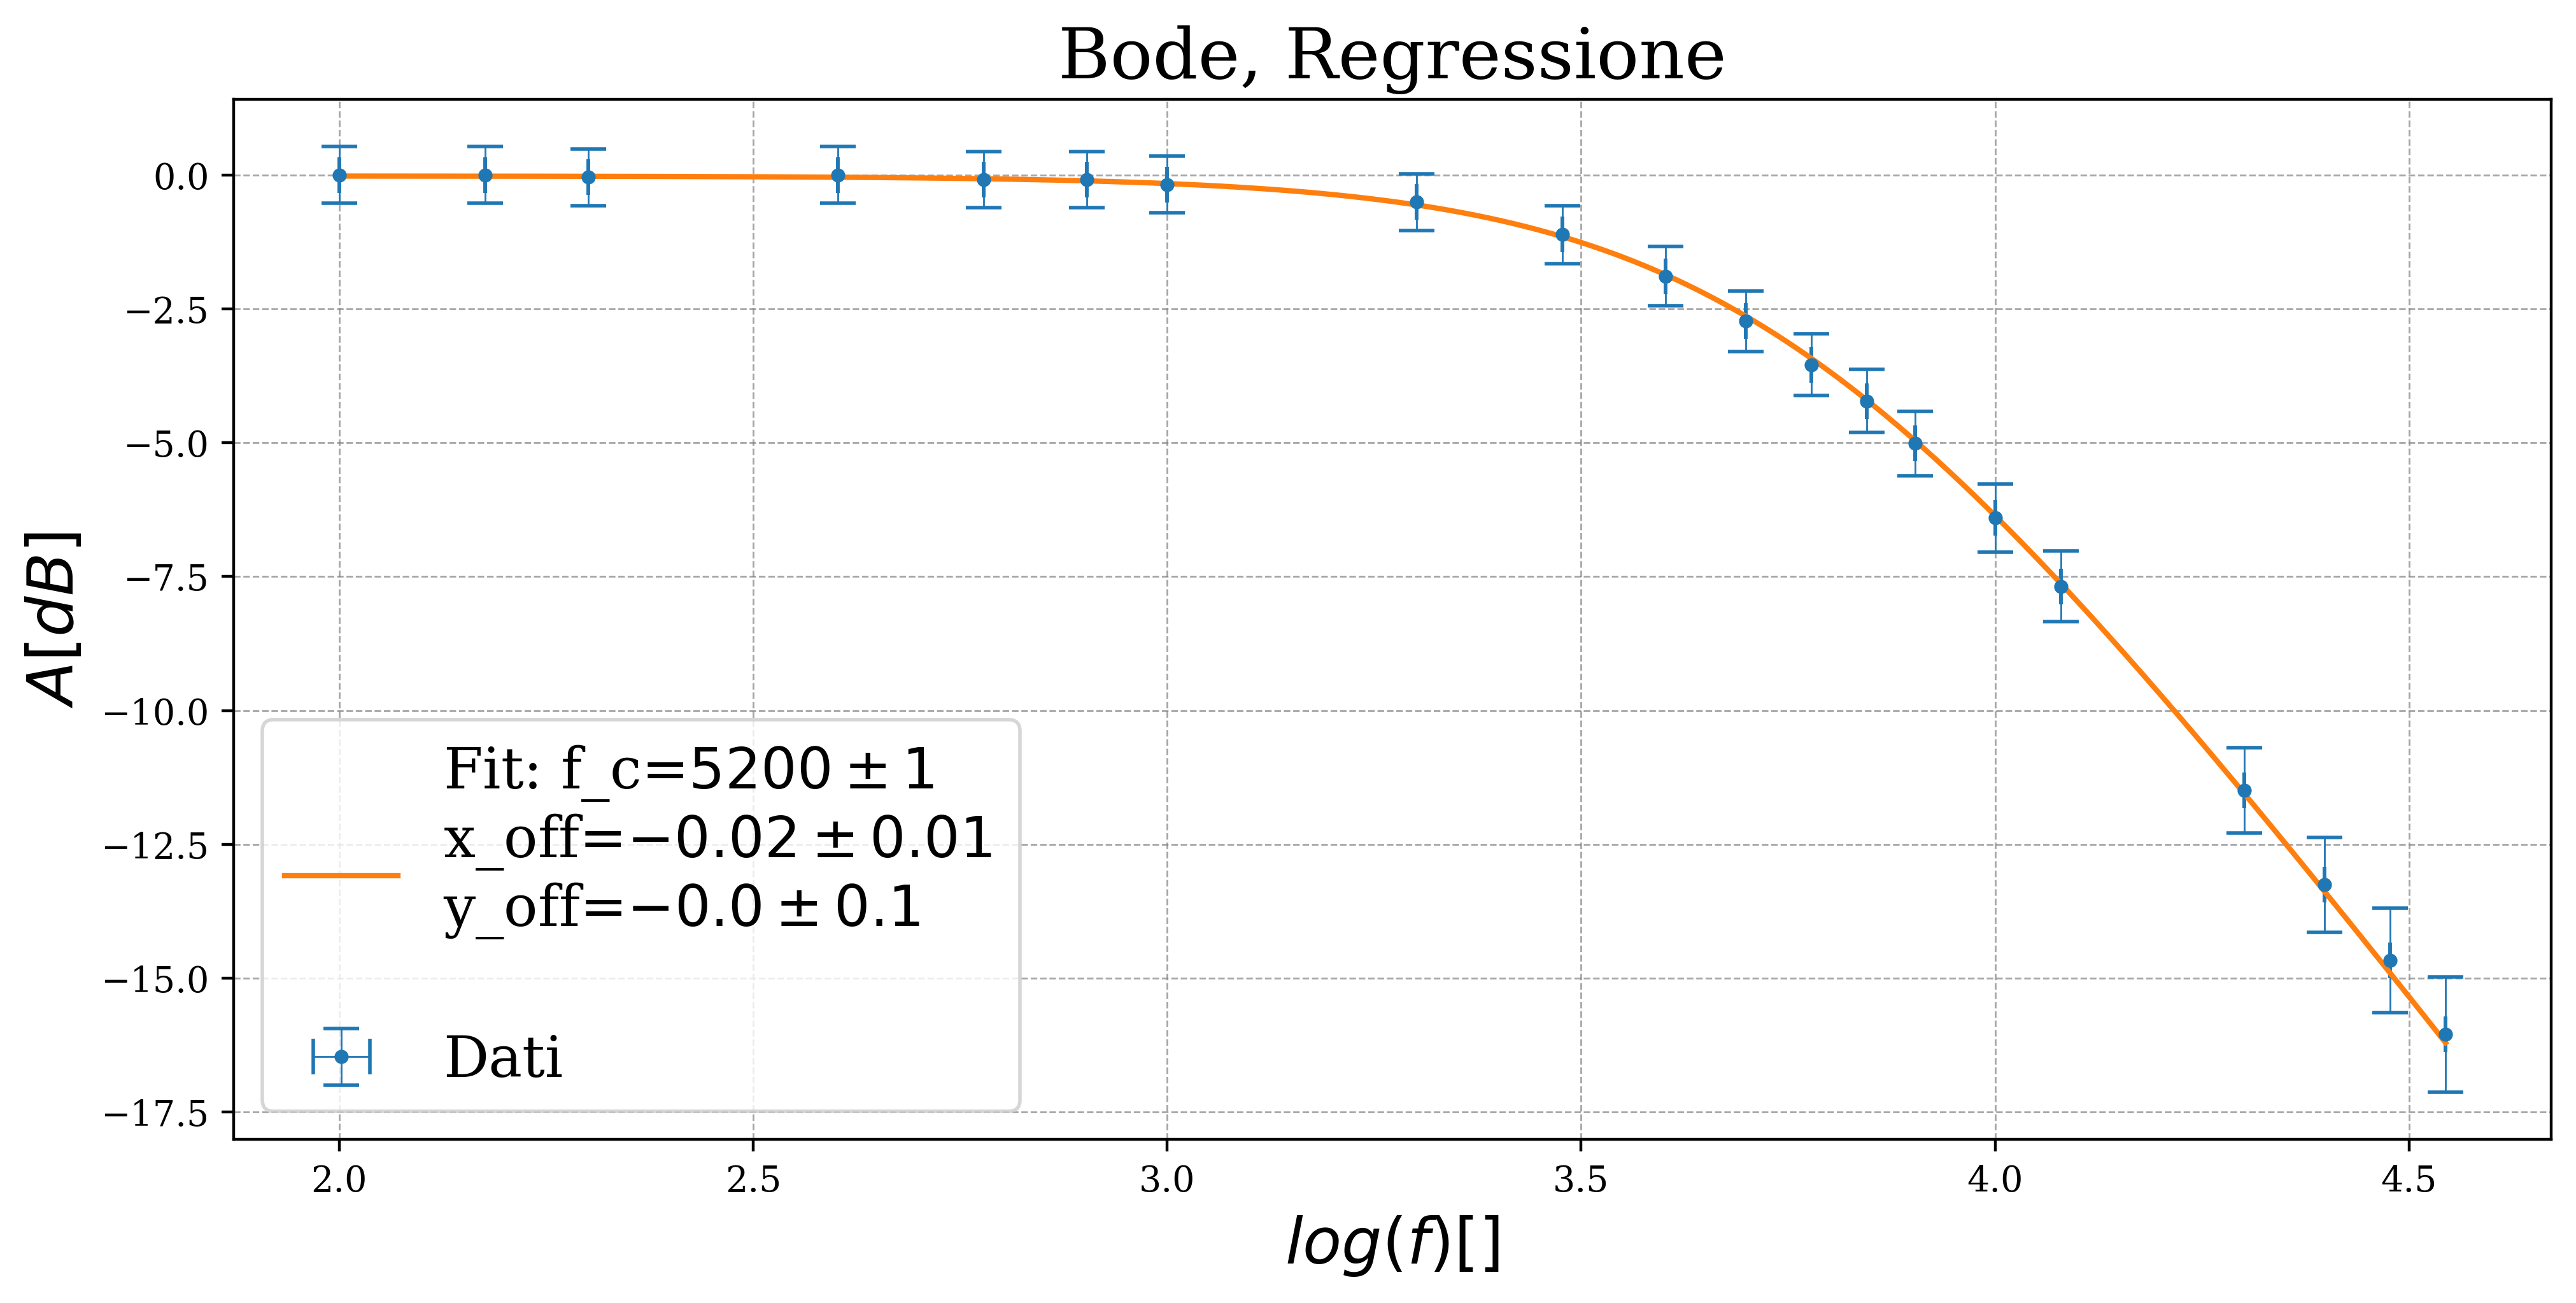

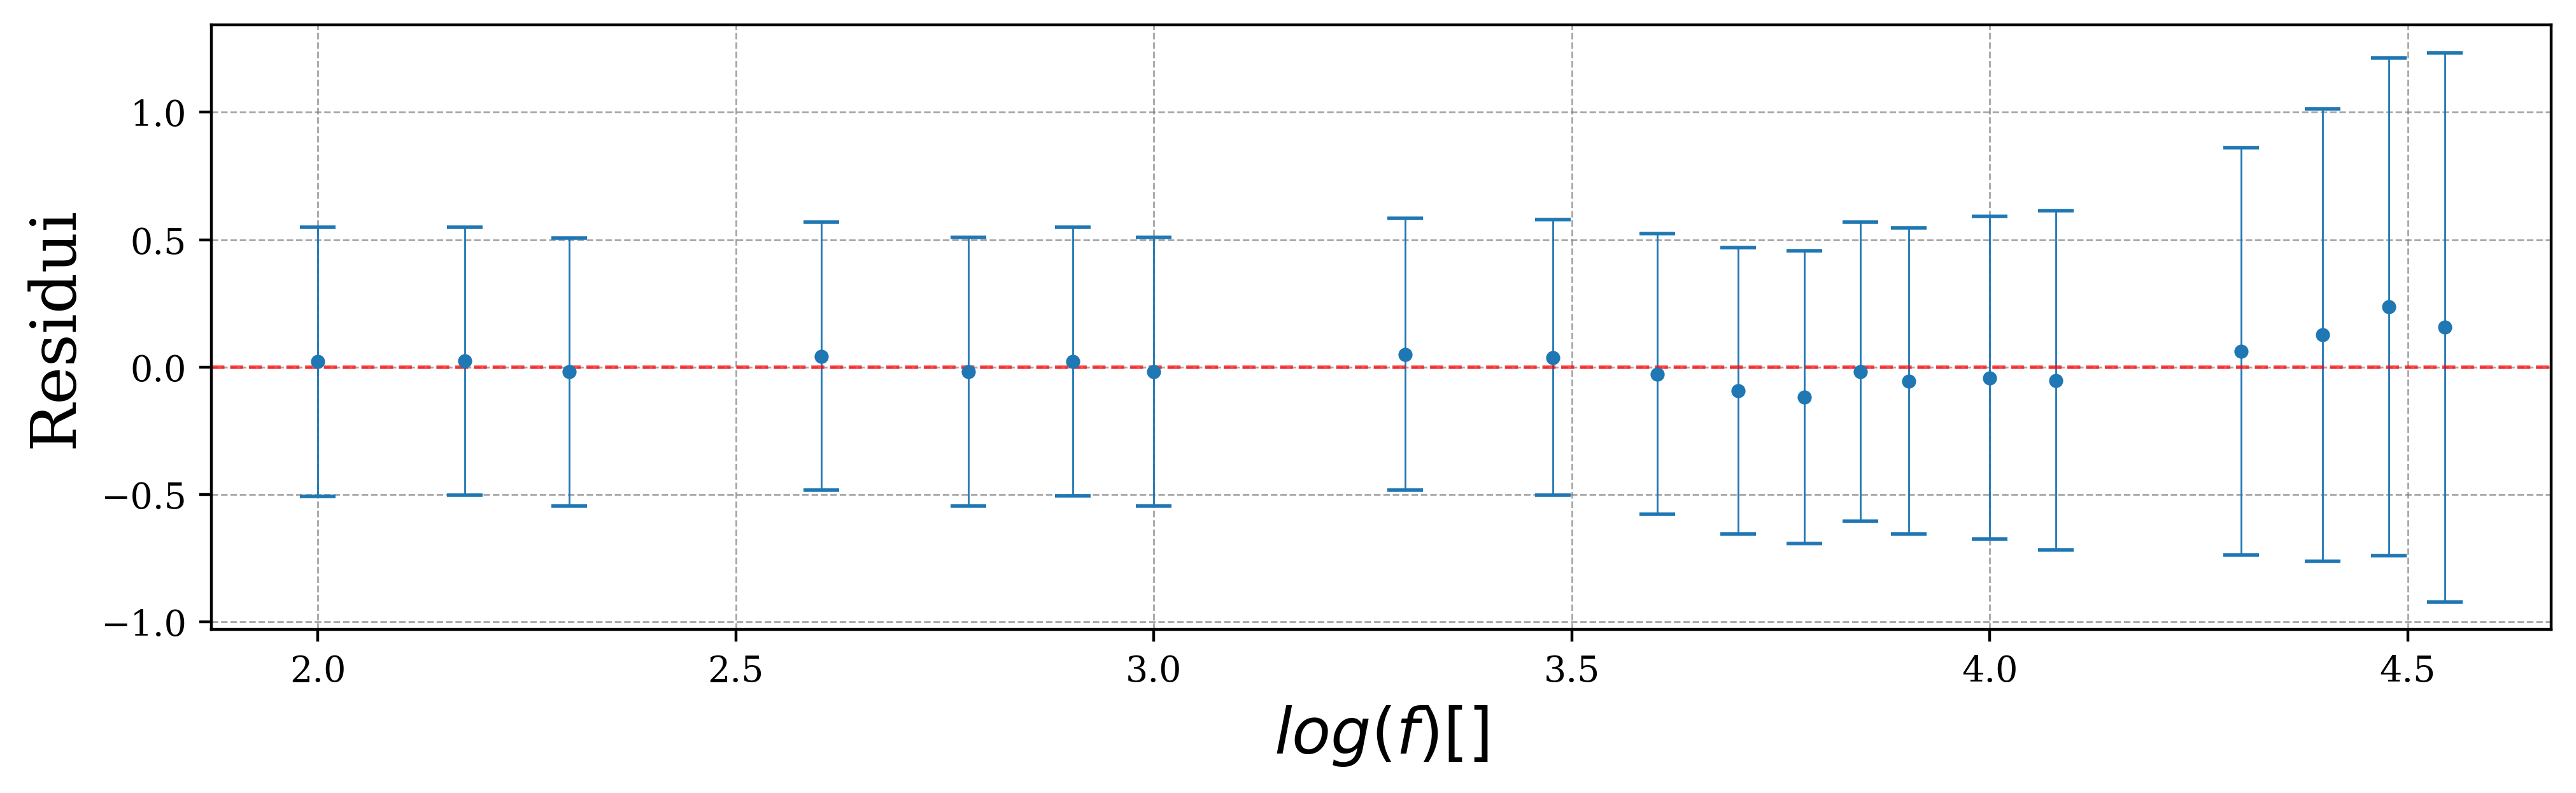

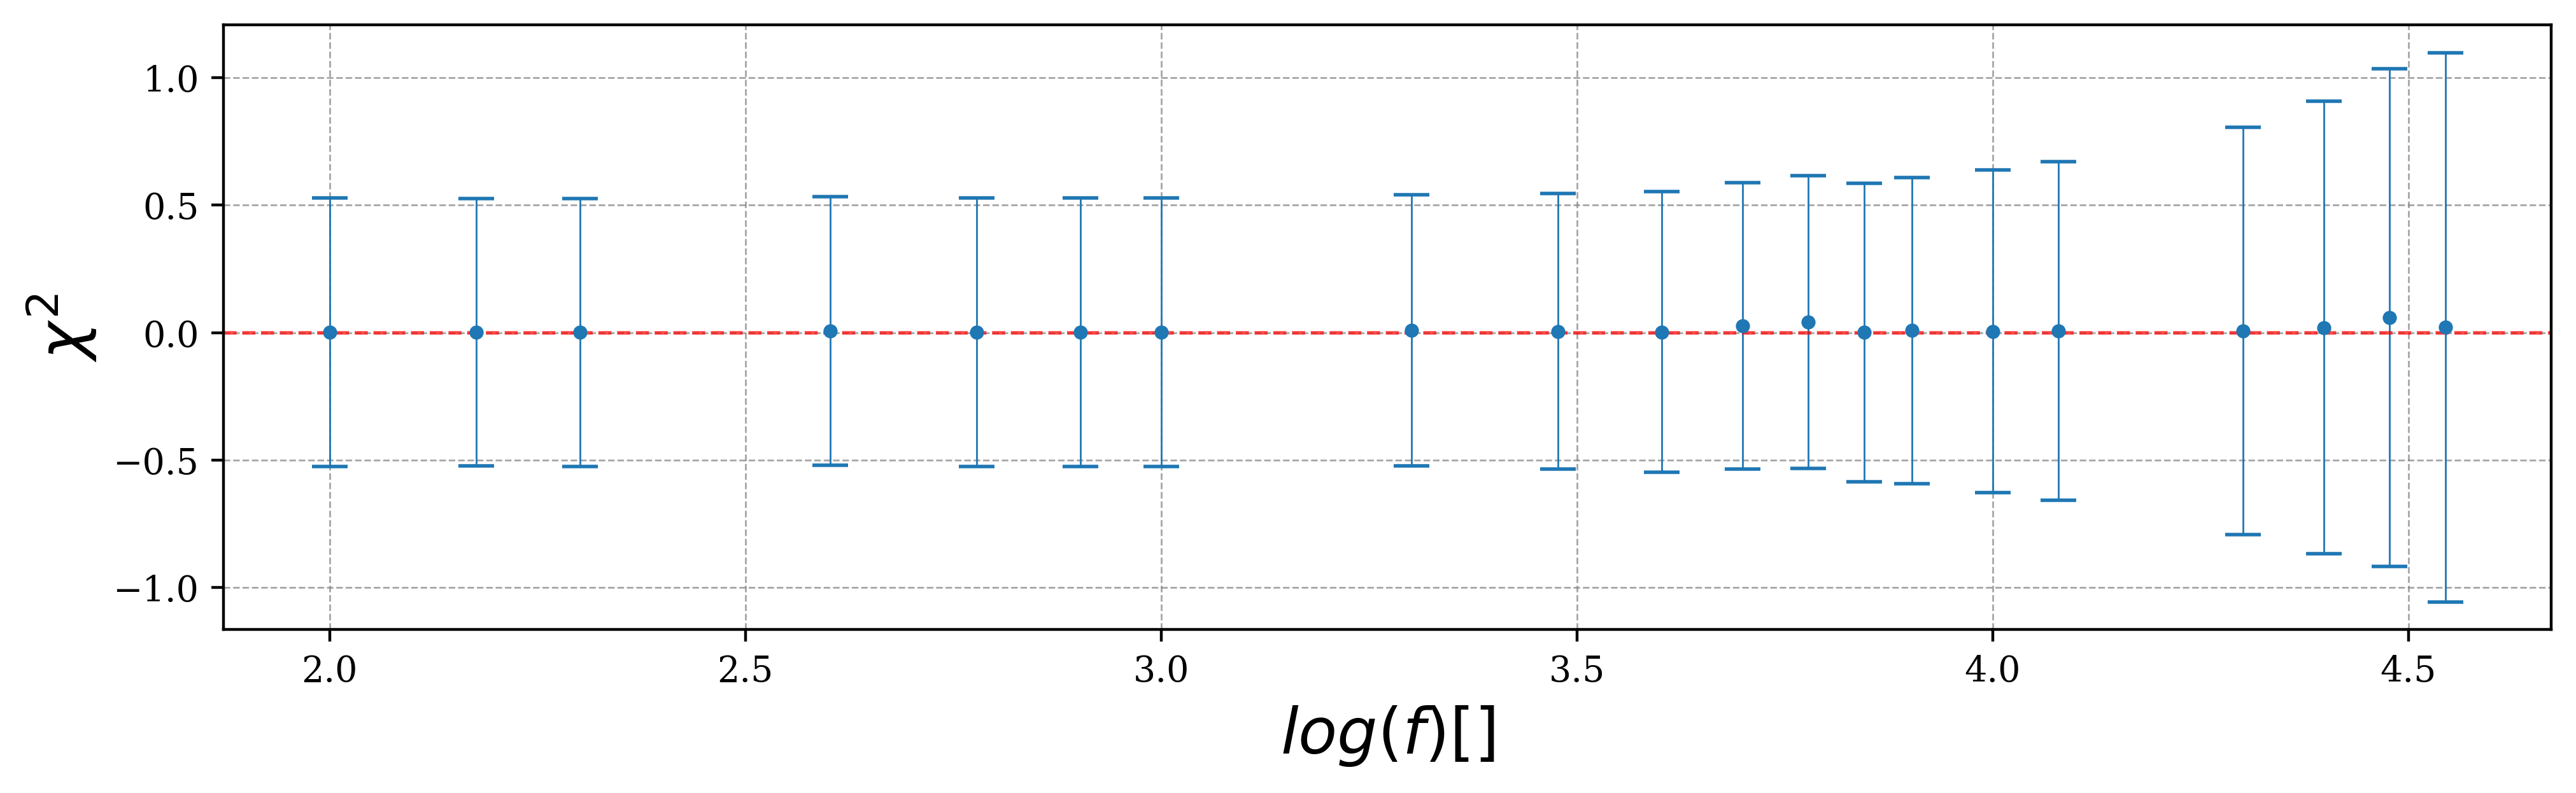

In [8]:
risultati = analizza("bode.json", modello, param_labels, beta0)

In [9]:
print(risultati)

Parametri regressione :
5200.050002138249 ± 0.9999999992923402
-0.024125995694025456 ± 0.014017713425758362
-0.020431698636115235 ± 0.12787570142250945

Somma residui :
0.3270
Somma chi quadri e chi ridotto :
0.2269
0.0133



In [10]:
risultati_dict = let.ris_fit_to_dict(risultati)
gf.display_dizionario(risultati_dict)
let.esporta_pickle(risultati_dict, filename = f"bode.pkl")

parametri,[ 5.20005000e+03 -2.41259957e-02 -2.04316986e-02]
s_parametri,[1. 0.01401771 0.1278757 ]
res,0.3269876942276451
chi,0.2269068965240458
chi_ridotto,0.013347464501414458
